In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


In [3]:
data = yf.download("SPLV", period="max")
data.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,SPLV,SPLV,SPLV,SPLV,SPLV
Date,,,,,
2011-05-05,17.606972,17.720611,17.564356,17.670893,42900
2011-05-06,17.699312,17.812951,17.663800,17.812951,12500
2011-05-09,17.699312,17.699312,17.685107,17.685107,600
2011-05-10,17.933685,17.947891,17.891071,17.891071,9700
2011-05-11,17.834251,17.926583,17.798738,17.919480,28900


In [6]:
import pandas as pd

# Create a DataFrame first - this is what was missing
# Example: Creating a sample DataFrame with stock price data
data = {
    'Date': pd.date_range(start='2023-01-01', periods=30),
    'Close': [100, 102, 104, 103, 105, 107, 108, 109, 110, 112,
              111, 113, 114, 115, 116, 117, 118, 117, 119, 120,
              121, 122, 123, 124, 125, 126, 127, 128, 129, 130]
}
df = pd.DataFrame(data)

# Now we can calculate moving averages
df['MA5'] = df['Close'].rolling(window=5).mean()
df['MA10'] = df['Close'].rolling(window=10).mean()
df.dropna(inplace=True)  # remove NaN rows from rolling calculations

# Display the DataFrame
print(df)

         Date  Close    MA5   MA10
9  2023-01-10    112  109.2  106.0
10 2023-01-11    111  110.0  107.1
11 2023-01-12    113  111.0  108.2
12 2023-01-13    114  112.0  109.2
13 2023-01-14    115  113.0  110.4
14 2023-01-15    116  113.8  111.5
15 2023-01-16    117  115.0  112.5
16 2023-01-17    118  116.0  113.5
17 2023-01-18    117  116.6  114.3
18 2023-01-19    119  117.4  115.2
19 2023-01-20    120  118.2  116.0
20 2023-01-21    121  119.0  117.0
21 2023-01-22    122  119.8  117.9
22 2023-01-23    123  121.0  118.8
23 2023-01-24    124  122.0  119.7
24 2023-01-25    125  123.0  120.6
25 2023-01-26    126  124.0  121.5
26 2023-01-27    127  125.0  122.4
27 2023-01-28    128  126.0  123.5
28 2023-01-29    129  127.0  124.5
29 2023-01-30    130  128.0  125.5


In [7]:
df['Target'] = df['Close'].shift(-1)
df.dropna(inplace=True)

X = df[['Close', 'MA5', 'MA10']]
y = df['Target']

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

model = LinearRegression()
model.fit(X_train, y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [9]:
predictions = model.predict(X_test)
mse = mean_squared_error(y_test, predictions)
print("Mean Squared Error:", mse)

# For a quick check on one of the last predictions:
print("Last predicted price:", predictions[-1])
print("Actual price:", y_test.iloc[-1])


Mean Squared Error: 0.24471630492437635
Last predicted price: 129.49460751129783
Actual price: 130.0


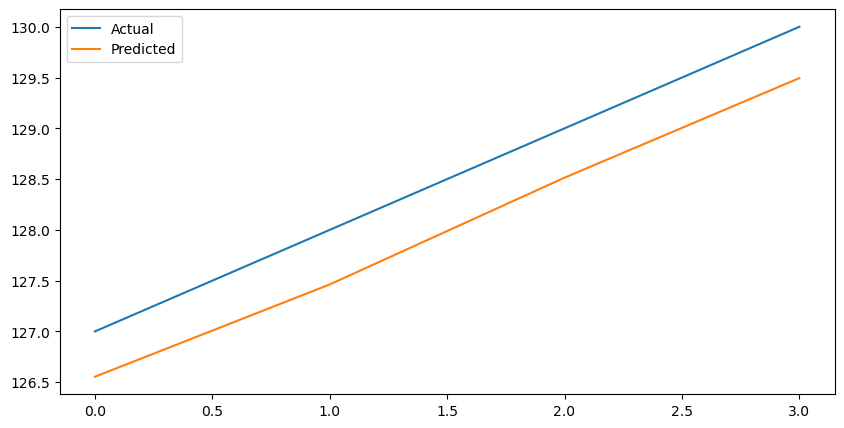

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(y_test.values, label='Actual')
plt.plot(predictions, label='Predicted')
plt.legend()
plt.show()


In [11]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# 1. Download all available SPLV data
df = yf.download("SPLV", period="max")

# 2. Create features (moving averages)
df['MA5'] = df['Close'].rolling(window=5).mean()
df['MA10'] = df['Close'].rolling(window=10).mean()
df.dropna(inplace=True)

# 3. Target: next day's close
df['Target'] = df['Close'].shift(-1)
df.dropna(inplace=True)

# 4. Features (X) and target (y)
X = df[['Close', 'MA5', 'MA10']]
y = df['Target']

# 5. Train / test split for evaluation
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

model = LinearRegression()
model.fit(X_train, y_train)

predictions = model.predict(X_test)
mse = mean_squared_error(y_test, predictions)
print("Test Mean Squared Error:", mse)


[*********************100%***********************]  1 of 1 completed

Test Mean Squared Error: 0.21736664501894346


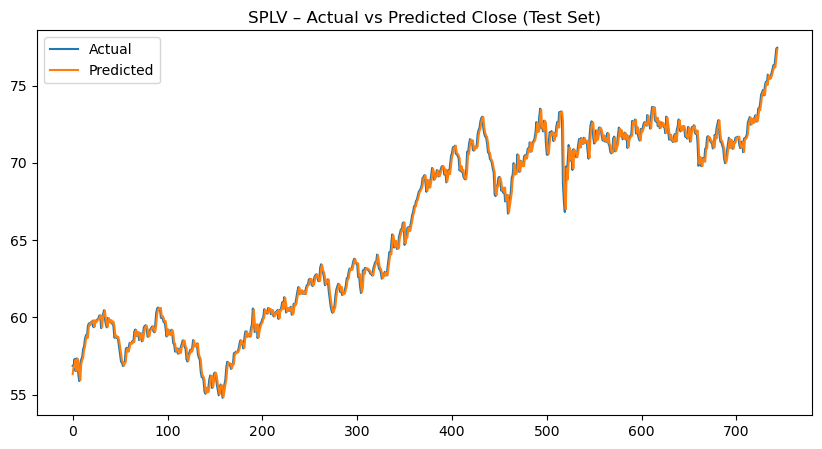

In [12]:
plt.figure(figsize=(10, 5))
plt.plot(y_test.values, label='Actual')
plt.plot(predictions, label='Predicted')
plt.legend()
plt.title("SPLV – Actual vs Predicted Close (Test Set)")
plt.show()


In [14]:
# Retrain on ALL data to use every point
model.fit(X, y)

# Take the most recent row to build features
last_row = df.iloc[-1]

# Create a properly formatted 2D array (with a single row)
# Remove the extra brackets that were creating a 3D structure
latest_features = [
    last_row['Close'],
    last_row['MA5'],
    last_row['MA10']
]

# Reshape to ensure it's a 2D array with shape (1, n_features)
import numpy as np
latest_features = np.array(latest_features).reshape(1, -1)

next_day_pred = model.predict(latest_features)[0]
print("Predicted next-day SPLV closing price:", next_day_pred)

Predicted next-day SPLV closing price: 77.36481489854407


In [15]:
import yfinance as yf
import pandas as pd

# All SPLV history
df = yf.download("SPLV", period="max")

# Features: moving averages
df['MA5'] = df['Close'].rolling(window=5).mean()
df['MA10'] = df['Close'].rolling(window=10).mean()

# Drop rows with NaNs from rolling windows
df.dropna(inplace=True)

# Target: next day's close
df['Target'] = df['Close'].shift(-1)
df.dropna(inplace=True)

# Features matrix X and target vector y
X = df[['Close', 'MA5', 'MA10']]
y = df['Target']


[*********************100%***********************]  1 of 1 completed


In [16]:
from sklearn.model_selection import train_test_split

# 80% train, 20% test, keep time order (no shuffle)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)


In [17]:
from sklearn.linear_model import LinearRegression

# Create the model
model = LinearRegression()

# Train (fit) the model on the training data
model.fit(X_train, y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [18]:
from sklearn.metrics import mean_squared_error

# Predict on the test set
predictions = model.predict(X_test)

# Simple error metric
mse = mean_squared_error(y_test, predictions)
print("Test Mean Squared Error:", mse)


Test Mean Squared Error: 0.21736645742007557


In [19]:
model.fit(X, y)  # train on full history


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [25]:
import numpy as np

last_row = df.iloc[-1]

# Make sure we pass a 2D numeric array: shape (1, 3)
latest_features = np.array([
    [
        float(last_row['Close']),
        float(last_row['MA5']),
        float(last_row['MA10'])
    ]
])

next_day_pred = model.predict(latest_features)[0]
print("Predicted next-day SPLV close:", next_day_pred)


Predicted next-day SPLV close: 77.36481461065638


/var/folders/93/mfltrdgj753dg0hq3k801gwh0000gn/T/ipykernel_29204/2536694951.py:8: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  float(last_row['Close']),
/var/folders/93/mfltrdgj753dg0hq3k801gwh0000gn/T/ipykernel_29204/2536694951.py:9: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  float(last_row['MA5']),
/var/folders/93/mfltrdgj753dg0hq3k801gwh0000gn/T/ipykernel_29204/2536694951.py:10: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  float(last_row['MA10'])
